<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/01_data_loading_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Try Google Drive mount first
# If auth fails, set USE_DRIVE = False and run next cell to upload manually
import pandas as pd
import numpy as np

USE_DRIVE = True

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_combined.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    USE_DRIVE = False
    print("Drive mount failed. Run next cell to upload manually.")

Mounted at /content/drive
Loaded from Drive: (2830743, 79)


In [ ]:
# Manual upload — skip this cell if Drive mount succeeded
if not USE_DRIVE:
    from google.colab import files
    uploaded = files.upload()  # select cicids2017_combined.csv
    data = pd.read_csv('cicids2017_combined.csv')
    print(f"Loaded from upload: {data.shape}")

In [ ]:
# Check label distribuation
print(data[' Label'].value_counts())

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


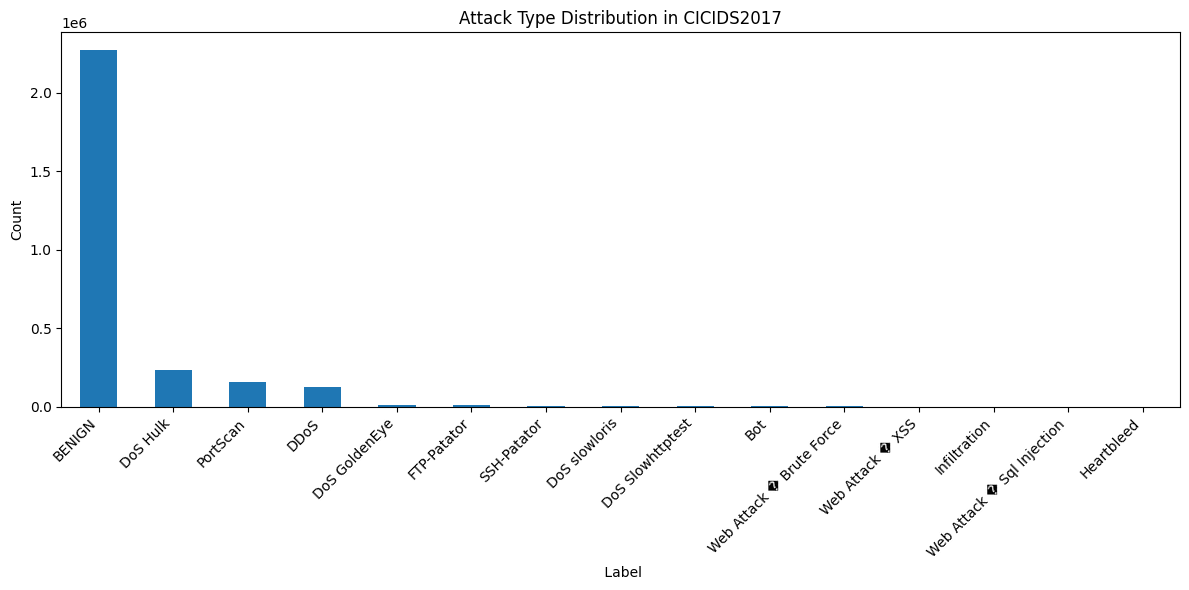

In [ ]:
# Visualise attack patterns
import matplotlib.pyplot as plt

label_counts = data[' Label'].value_counts()
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Attack Type Distribution in CICIDS2017')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Basic data shapes
print(f"Columns: {data.shape[1]}")
print(f"\nMissing values:\n{data.isnull().sum()[data.isnull().sum() > 0]}")
print(f"\nData types:\n{data.dtypes.value_counts()}")

Columns: 79

Missing values:
Flow Bytes/s    1358
dtype: int64

Data types:
int64      54
float64    24
object      1
Name: count, dtype: int64


In [ ]:
# Preprocessing
data.columns = data.columns.str.strip()
print(data.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
import numpy as np

# Replace infinite values with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Check missing values
missing = data.isnull().sum()
print(f"Columns with missing values:\n{missing[missing > 0]}")

# Drop rows with missing values
before = len(data)
data.dropna(inplace=True)
print(f"\nRows removed: {before - len(data)}")
print(f"Remaining data: {data.shape}")

Columns with missing values:
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64

Rows removed: 2867
Remaining data: (2827876, 79)


In [ ]:
# Labeling
print(data['Label'].value_counts())

# Create binary label: BENIGN=0, Attack=1
data['is_attack'] = (data['Label'] != 'BENIGN').astype(int)
print(f"\nBenign: {(data['is_attack']==0).sum()}")
print(f"Attack: {(data['is_attack']==1).sum()}")

Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Benign: 2271320
Attack: 556556


In [ ]:
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove('is_attack')
print(f"Number of features: {len(feature_cols)}")

X = data[feature_cols]
y = data['is_attack']
print(f"X: {X.shape}, y: {y.shape}")

Number of features: 78
X: (2827876, 78), y: (2827876,)
